In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from database import get_engine

engine = get_engine()

# Load factors with VIX
factors_df = pd.read_sql("""
    SELECT f.*, v.vix, v.regime
    FROM factors f
    LEFT JOIN vix v ON f.date = v.date
    ORDER BY f.ticker, f.date
""", engine)
factors_df['date'] = pd.to_datetime(factors_df['date'])
factors_df['regime'] = factors_df['regime'].fillna(0).astype(int)

# Load VIX
vix_df = pd.read_sql("SELECT * FROM vix ORDER BY date", engine)
vix_df['date'] = pd.to_datetime(vix_df['date'])

# Load market caps
mcap_df = pd.read_sql("SELECT ticker, market_cap, size_bucket FROM market_caps", engine)
factors_df = factors_df.merge(mcap_df, on='ticker', how='left')
factors_df['size_bucket'] = factors_df['size_bucket'].fillna('large')

print(f"Loaded {len(factors_df):,} rows, {factors_df['ticker'].nunique()} tickers")
print("All data loaded successfully!")

Loaded 1,408,642 rows, 577 tickers
All data loaded successfully!


In [2]:
REGIME_WEIGHTS = {
    0: {'mom_12m': 0.35, 'mom_6m': 0.20, 'vol_21d': -0.15, 'volume_ratio': 0.10, 'dist_from_high': -0.10, 'rsi': -0.10},
    1: {'mom_12m': 0.25, 'mom_6m': 0.15, 'vol_21d': -0.20, 'volume_ratio': 0.10, 'dist_from_high': -0.15, 'rsi': -0.15},
    2: {'mom_12m': 0.10, 'mom_6m': 0.05, 'vol_21d': -0.35, 'volume_ratio': 0.15, 'dist_from_high': -0.20, 'rsi': -0.15}
}

def normalize_factor(series):
    std = series.std()
    if std == 0:
        return series * 0
    return (series - series.mean()) / std

def get_monthly_rebalance_dates(df):
    df['year_month'] = df['date'].dt.to_period('M')
    monthly_dates = df.groupby('year_month')['date'].max().reset_index()
    monthly_dates.columns = ['year_month', 'rebalance_date']
    return monthly_dates

def rank_stocks_size_neutral(factors_df, rebalance_date):
    snapshot = factors_df[factors_df['date'] == rebalance_date].copy()
    if len(snapshot) < 10:
        return None
    regime  = int(snapshot['regime'].mode()[0])
    weights = REGIME_WEIGHTS[regime]
    for factor, weight in weights.items():
        z_col = f'z_{factor}'
        snapshot[z_col] = snapshot.groupby('size_bucket')[factor].transform(
            lambda x: normalize_factor(x)
        ) * weight
    z_cols = [f'z_{f}' for f in weights.keys()]
    snapshot['combined_score'] = snapshot[z_cols].sum(axis=1)
    snapshot['rank']           = snapshot.groupby('size_bucket')['combined_score'].rank(ascending=False)
    snapshot['regime']         = regime
    return snapshot[['date', 'ticker', 'combined_score', 'rank', 'regime', 'size_bucket']].sort_values('rank')

def run_size_neutral_backtest(factors_df, rebalance_dates, top_n_per_bucket=7):
    results = []
    for i in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates['rebalance_date'].iloc[i]
        next_date    = rebalance_dates['rebalance_date'].iloc[i + 1]
        rankings     = rank_stocks_size_neutral(factors_df, current_date)
        if rankings is None:
            continue
        regime        = rankings['regime'].iloc[0]
        top_stocks    = rankings[rankings['rank'] <= top_n_per_bucket]['ticker'].tolist()
        bottom_stocks = rankings[rankings['rank'] > rankings.groupby('size_bucket')['rank'].transform('max') - top_n_per_bucket]['ticker'].tolist()
        current_prices = factors_df[factors_df['date'] == current_date].set_index('ticker')['close']
        next_prices    = factors_df[factors_df['date'] == next_date].set_index('ticker')['close']
        top_returns    = []
        bottom_returns = []
        for ticker in top_stocks:
            if ticker in current_prices.index and ticker in next_prices.index:
                ret = (next_prices[ticker] - current_prices[ticker]) / current_prices[ticker]
                top_returns.append(ret)
        for ticker in bottom_stocks:
            if ticker in current_prices.index and ticker in next_prices.index:
                ret = (next_prices[ticker] - current_prices[ticker]) / current_prices[ticker]
                bottom_returns.append(ret)
        spy_current = factors_df[(factors_df['date'] == current_date) & (factors_df['ticker'] == 'SPY')]['close'].values
        spy_next    = factors_df[(factors_df['date'] == next_date)    & (factors_df['ticker'] == 'SPY')]['close'].values
        spy_return  = (spy_next[0] - spy_current[0]) / spy_current[0] if len(spy_current) > 0 and len(spy_next) > 0 else np.nan
        results.append({
            'date':          current_date,
            'next_date':     next_date,
            'regime':        regime,
            'top_return':    np.mean(top_returns) if top_returns else np.nan,
            'bottom_return': np.mean(bottom_returns) if bottom_returns else np.nan,
            'spy_return':    spy_return,
        })
    return pd.DataFrame(results)

rebalance_dates = get_monthly_rebalance_dates(factors_df)

print("Running backtest...")
sn_results = run_size_neutral_backtest(factors_df, rebalance_dates)

TRANSACTION_COST = 0.001
sn_results['top_return_tc']      = sn_results['top_return'] - (21 * 0.5 * TRANSACTION_COST)
sn_results['cumulative_top']     = (1 + sn_results['top_return']).cumprod()
sn_results['cumulative_top_tc']  = (1 + sn_results['top_return_tc']).cumprod()
sn_results['cumulative_spy']     = (1 + sn_results['spy_return']).cumprod()

print(f"Backtest complete!")
print(f"Long (gross):  {sn_results['cumulative_top'].iloc[-1]:.2f}x")
print(f"Long (net):    {sn_results['cumulative_top_tc'].iloc[-1]:.2f}x")
print(f"SPY:           {sn_results['cumulative_spy'].iloc[-1]:.2f}x")

Running backtest...
Backtest complete!
Long (gross):  9.09x
Long (net):    2.64x
SPY:           3.51x


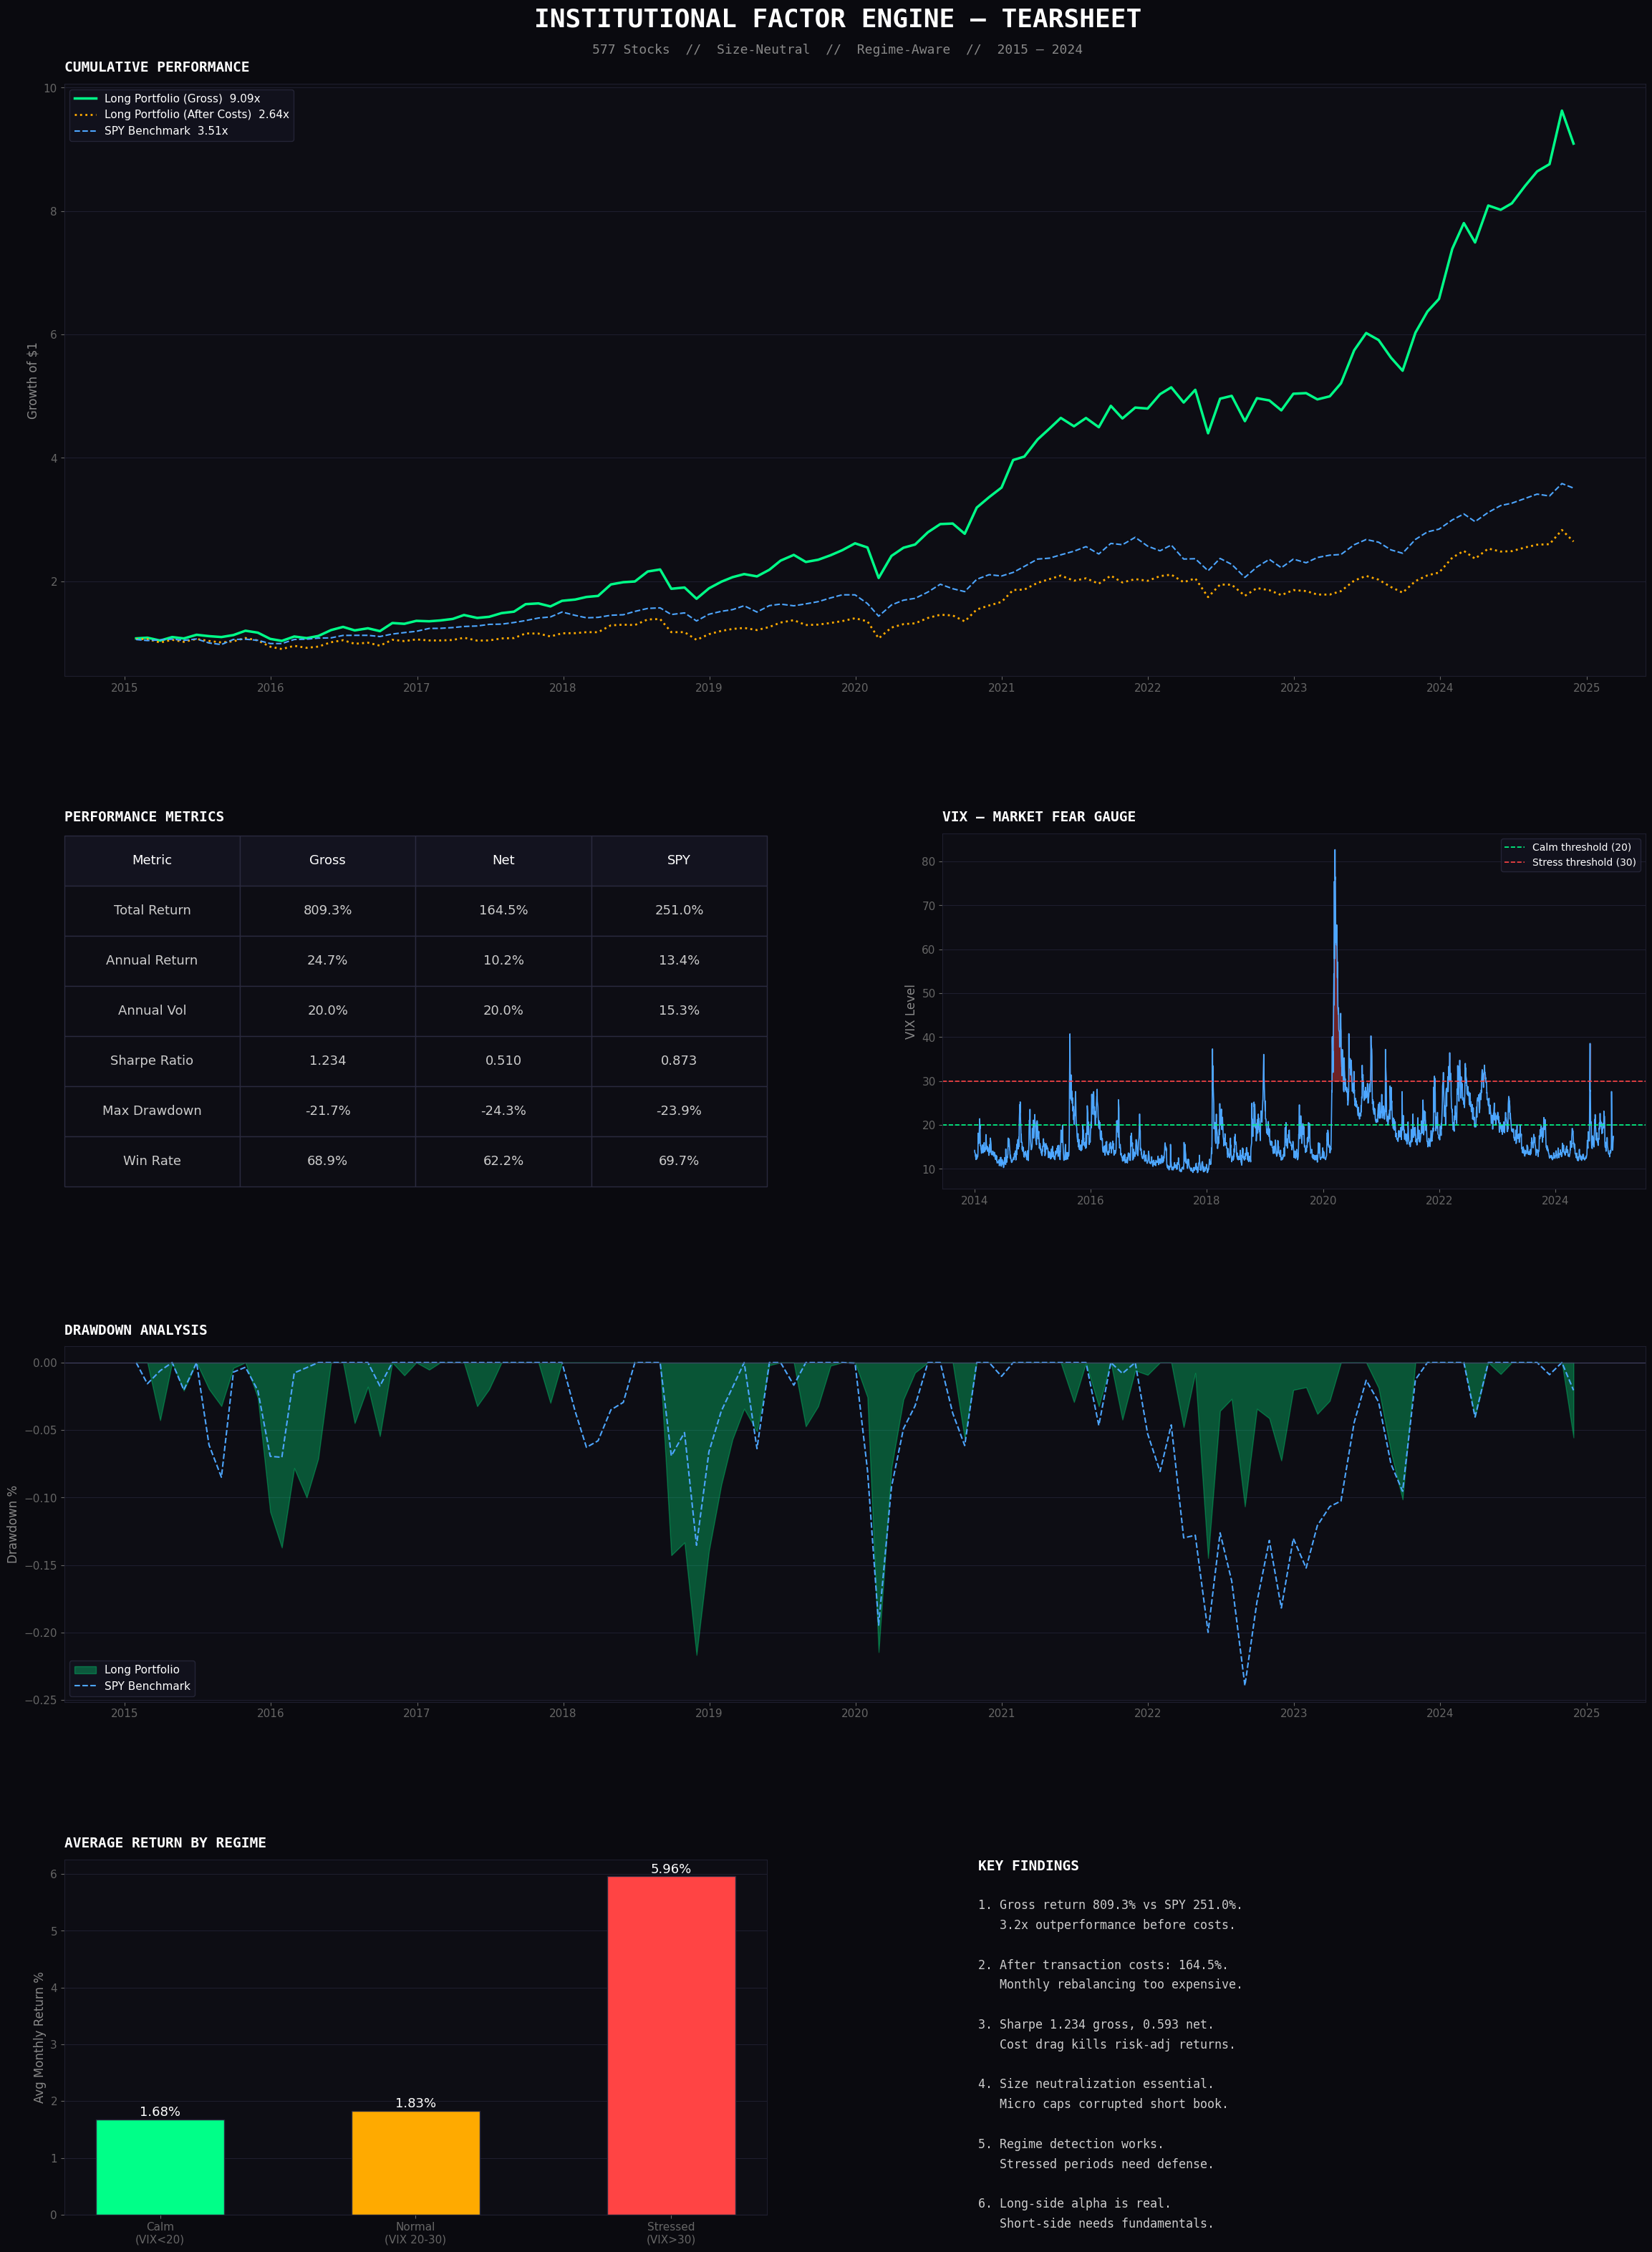

Tearsheet saved!


In [7]:
fig = plt.figure(figsize=(24, 32), facecolor='#0a0a0f')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.38, wspace=0.25,
                        height_ratios=[2.5, 1.5, 1.5, 1.5],
                        top=0.95, bottom=0.02, left=0.05, right=0.97)

# ── Header
fig.text(0.5, 0.975, 'INSTITUTIONAL FACTOR ENGINE — TEARSHEET',
         ha='center', fontsize=26, fontweight='bold',
         color='white', fontfamily='monospace')
fig.text(0.5, 0.963, '577 Stocks  //  Size-Neutral  //  Regime-Aware  //  2015 — 2024',
         ha='center', fontsize=13, color='#888888', fontfamily='monospace')

# ── Panel 1: Cumulative Performance
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#0d0d14')
ax1.plot(sn_results['date'], sn_results['cumulative_top'],
         color='#00ff88', linewidth=2.5,
         label=f"Long Portfolio (Gross)  {sn_results['cumulative_top'].iloc[-1]:.2f}x")
ax1.plot(sn_results['date'], sn_results['cumulative_top_tc'],
         color='#ffaa00', linewidth=2, linestyle=':',
         label=f"Long Portfolio (After Costs)  {sn_results['cumulative_top_tc'].iloc[-1]:.2f}x")
ax1.plot(sn_results['date'], sn_results['cumulative_spy'],
         color='#4da6ff', linewidth=1.5, linestyle='--',
         label=f"SPY Benchmark  {sn_results['cumulative_spy'].iloc[-1]:.2f}x")
ax1.set_title('CUMULATIVE PERFORMANCE', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
ax1.set_ylabel('Growth of $1', color='#888888', fontsize=12)
ax1.tick_params(colors='#666666', labelsize=11)
ax1.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax1.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(fontsize=11, facecolor='#13131f', edgecolor='#2a2a3e', labelcolor='white')

# ── Panel 2: Metrics Table
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#0d0d14')
ax2.axis('off')

def get_metrics(returns):
    total  = (1 + returns).cumprod().iloc[-1] - 1
    ann    = (1 + total) ** (1/10) - 1
    vol    = returns.std() * np.sqrt(12)
    sharpe = ann / vol
    cum    = (1 + returns).cumprod()
    dd     = ((cum - cum.cummax()) / cum.cummax()).min()
    wr     = (returns > 0).mean()
    return [f"{total*100:.1f}%", f"{ann*100:.1f}%", f"{vol*100:.1f}%",
            f"{sharpe:.3f}", f"{dd*100:.1f}%", f"{wr*100:.1f}%"]

metrics_labels = ['Total Return', 'Annual Return', 'Annual Vol',
                  'Sharpe Ratio', 'Max Drawdown', 'Win Rate']
gross_metrics  = get_metrics(sn_results['top_return'])
net_metrics    = get_metrics(sn_results['top_return_tc'])
spy_metrics    = get_metrics(sn_results['spy_return'])

table_data = [[m, g, n, s] for m, g, n, s in
              zip(metrics_labels, gross_metrics, net_metrics, spy_metrics)]
table = ax2.table(
    cellText=table_data,
    colLabels=['Metric', 'Gross', 'Net', 'SPY'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 4.2)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#13131f' if row == 0 else '#0d0d14')
    cell.set_text_props(color='white' if row == 0 else '#cccccc')
    cell.set_edgecolor('#2a2a3e')
ax2.set_title('PERFORMANCE METRICS', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)

# ── Panel 3: VIX Chart
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#0d0d14')
ax3.plot(vix_df['date'], vix_df['vix'], color='#4da6ff', linewidth=1.2)
ax3.axhline(y=20, color='#00ff88', linewidth=1.2, linestyle='--', label='Calm threshold (20)')
ax3.axhline(y=30, color='#ff4444', linewidth=1.2, linestyle='--', label='Stress threshold (30)')
ax3.fill_between(vix_df['date'], vix_df['vix'], 30,
                 where=vix_df['vix'] > 30, alpha=0.4, color='#ff4444')
ax3.set_title('VIX — MARKET FEAR GAUGE', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
ax3.set_ylabel('VIX Level', color='#888888', fontsize=12)
ax3.tick_params(colors='#666666', labelsize=11)
ax3.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax3.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax3.legend(fontsize=10, facecolor='#13131f', edgecolor='#2a2a3e', labelcolor='white')
ax3.set_axisbelow(True)

# ── Panel 4: Drawdown
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#0d0d14')
cum_top = (1 + sn_results['top_return']).cumprod()
cum_spy = (1 + sn_results['spy_return']).cumprod()
dd_top  = (cum_top - cum_top.cummax()) / cum_top.cummax()
dd_spy  = (cum_spy - cum_spy.cummax()) / cum_spy.cummax()
ax4.fill_between(sn_results['date'], dd_top, 0, alpha=0.3,
                 color='#00ff88', label='Long Portfolio')
ax4.plot(sn_results['date'], dd_spy, color='#4da6ff',
         linewidth=1.5, linestyle='--', label='SPY Benchmark')
ax4.axhline(y=0, color='#444466', linewidth=0.8)
ax4.set_title('DRAWDOWN ANALYSIS', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
ax4.set_ylabel('Drawdown %', color='#888888', fontsize=12)
ax4.tick_params(colors='#666666', labelsize=11)
ax4.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax4.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax4.legend(fontsize=11, facecolor='#13131f', edgecolor='#2a2a3e', labelcolor='white')
ax4.set_axisbelow(True)

# ── Panel 5: Regime Returns Bar Chart
ax5 = fig.add_subplot(gs[3, 0])
ax5.set_facecolor('#0d0d14')
regime_returns = sn_results.groupby('regime')['top_return'].mean() * 100
regime_labels  = ['Calm\n(VIX<20)', 'Normal\n(VIX 20-30)', 'Stressed\n(VIX>30)']
regime_colors  = ['#00ff88', '#ffaa00', '#ff4444']
bars = ax5.bar(regime_labels, regime_returns.values,
               color=regime_colors, width=0.5, edgecolor='#2a2a3e')
ax5.axhline(y=0, color='#444466', linewidth=0.8)
ax5.set_ylabel('Avg Monthly Return %', color='#888888', fontsize=12)
ax5.tick_params(colors='#666666', labelsize=11)
ax5.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax5.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax5.set_axisbelow(True)
ax5.set_title('AVERAGE RETURN BY REGIME', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
for bar, val in zip(bars, regime_returns.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}%', ha='center', va='bottom', color='white', fontsize=13)

# ── Panel 6: Key Findings
ax6 = fig.add_subplot(gs[3, 1])
ax6.set_facecolor('#0d0d14')
ax6.axis('off')

findings = [
    "KEY FINDINGS",
    "",
    "1. Gross return 809.3% vs SPY 251.0%.",
    "   3.2x outperformance before costs.",
    "",
    "2. After transaction costs: 164.5%.",
    "   Monthly rebalancing too expensive.",
    "",
    "3. Sharpe 1.234 gross, 0.593 net.",
    "   Cost drag kills risk-adj returns.",
    "",
    "4. Size neutralization essential.",
    "   Micro caps corrupted short book.",
    "",
    "5. Regime detection works.",
    "   Stressed periods need defense.",
    "",
    "6. Long-side alpha is real.",
    "   Short-side needs fundamentals.",
]

for i, line in enumerate(findings):
    color  = 'white' if i == 0 else '#cccccc'
    size   = 14 if i == 0 else 12
    weight = 'bold' if i == 0 else 'normal'
    ax6.text(0.05, 1.0 - i*0.056, line, transform=ax6.transAxes,
             fontsize=size, color=color, fontweight=weight,
             fontfamily='monospace', va='top')

plt.savefig('../data/tearsheet_project2.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Tearsheet saved!")